# Uncertainty Quantification for WDF Seasonal Forecasts

Uncertainty quantification for **WDF (Wet Day Frequency)** - the monthly rainfall occurrence rate [0,1].

**Key Technical Feature:** Uses **truncated normal distribution** N(μ,σ²) bounded to [0,1], with CRPS formulas from Jordan et al. (2019).


### Stage 1: Mean Prediction - completed in previous notebook
- **Model:** LinearRegression + ecmwf_mean (pooled)
- **Output:** Point forecasts μ̂ ∈ [0,1]

### Stage 2: Uncertainty Prediction - this notebook
- **Goal:** Predict forecast uncertainty σ
- **Distribution:** Truncated Normal N(μ,σ²) on [0,1]
- **Training:** CRPS loss for truncated normal
- **Baseline:** LOOCV residual-quantile intervals
- **Evaluation:** CRPS, Coverage (68%, 80%, 95%), Width

---

## Truncated Normal vs Regular Normal

**Why Truncated for WDF?**
- Physical constraint: WDF on [0,1]
- Regular normal can produce invalid predictions outside of [0,1]

**Mathematical Implications:**
- **CRPS Formula:** More complex formula - not simple like regular normal.
- **Coverage:** Calculated via truncated quantiles


## Why we use a softplus model for σ(x)

We must predict a **scale parameter** σ for a probabilistic distribution. By definition, **σ must be strictly positive**.

In this notebook we therefore parameterize σ using a softplus link function:

$$
\sigma(x)=\operatorname{softplus}(w x + b)+\varepsilon,\quad \varepsilon>0.
$$

This guarantees σ(x) > 0 for all inputs and makes the CRPS optimization numerically stable.

## Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import time
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

✅ Libraries imported successfully


## 2. Configuration

In [ ]:
# Target variable
TARGET = 'wdf'

# File paths (matching SPI notebook structure)
PREDICTIONS_DIR = '000000 Final Data/eastnor/model_results/predictions'
MEAN_PREDICTIONS_FILE = 'run_20251229_014845--LinearRegression--ecmwf_mean--wdf--all.csv'
ECMWF_DATA_FILE = '000000 Final Data/eastnor/3_eobs_ecmwf_merged_with_seasons.csv'

# All ECMWF features
ALL_ECMWF_FEATURES = [
    'ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
    'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar'
]

# Input configurations from Notebook 6 analysis
INPUT_CONFIGS_ALL = {
    'Config_1_Top2': ['ecmwf_temp_ensmean', 'ecmwf_precip_ensmean'],
    'Config_2_Means': ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean'],
    'Config_3_Variance': ['ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar'],
    'Config_4_All': ALL_ECMWF_FEATURES
}

# Model types to test
MODEL_TYPES_ALL = {
    'Linear': {},
    'Ridge_1.0': {'alpha': 1.0},
    'Ridge_10.0': {'alpha': 10.0},
    'Lasso_0.001': {'alpha': 0.001},
    'Lasso_0.01': {'alpha': 0.01}
}

DEBUG_SUBSET = True

if DEBUG_SUBSET:
    # Example: 4 configs × 3 models = 12 runs (fast sanity-check)
    INPUT_CONFIGS = {
        'Config_1_Top2': INPUT_CONFIGS_ALL['Config_1_Top2'],
        'Config_2_Means': INPUT_CONFIGS_ALL['Config_2_Means'],
        'Config_3_Variance': INPUT_CONFIGS_ALL['Config_3_Variance'],
        'Config_4_All': INPUT_CONFIGS_ALL['Config_4_All'],
    }
    MODEL_TYPES = {
        'Linear': MODEL_TYPES_ALL['Linear'],
        'Ridge_1.0': MODEL_TYPES_ALL['Ridge_1.0'],
        'Ridge_10.0': MODEL_TYPES_ALL['Ridge_10.0'],
        'Lasso_0.001': MODEL_TYPES_ALL['Lasso_0.001'],
    }
else:
    INPUT_CONFIGS = INPUT_CONFIGS_ALL
    MODEL_TYPES = MODEL_TYPES_ALL

# MLP configuration (set to False to exclude)
INCLUDE_MLP = False  # Set to True to include MLP in experiments
MLP_HIDDEN_UNITS = 16

print(f"\nDEBUG_SUBSET={DEBUG_SUBSET} → running {len(MODEL_TYPES)} models × {len(INPUT_CONFIGS)} configs = {len(MODEL_TYPES)*len(INPUT_CONFIGS)} runs")

# Training parameters
# We initialize models near a reasonable σ
CRPS_EPOCHS = 500
CRPS_LR = 2e-3

# Sigma initialization target
# SIGMA_INIT = 0.12 ORIGINAL
# SIGMA_INIT = 0.02
SIGMA_INIT = 0.2

# Coverage levels for evaluation
COVERAGE_LEVELS = [0.68, 0.80, 0.95]


DEBUG_SUBSET=True → running 4 models × 4 configs = 16 runs
TARGET: WDF
Mean model: LinearRegression + ecmwf_mean (pooled)
Input configs: 4
Model types: 4
Total experiments: 16


## 3. Load Data

In [ ]:
print("LOADING MEAN PREDICTIONS")
from pathlib import Path

# Construct full path
pred_dir = Path(PREDICTIONS_DIR)
pred_file = pred_dir / MEAN_PREDICTIONS_FILE

if not pred_file.exists():
    raise FileNotFoundError(f"Predictions file not found: {pred_file}")

# Load mean predictions from Notebook 5
mu_predictions = pd.read_csv(pred_file)

# Convert time to datetime
mu_predictions['time'] = pd.to_datetime(mu_predictions['time'])

# Calculate errors
mu_predictions['error'] = mu_predictions['y_pred'] - mu_predictions['y_true']
mu_predictions['abs_error'] = mu_predictions['error'].abs()

LOADING MEAN PREDICTIONS

✅ Mean predictions loaded: 368 samples
   y_true range: [0.036, 0.791]
   abs_error range: [0.000, 0.324]


### Merge with ECMWF Features

In [ ]:
# Load ECMWF features
data_file = Path(ECMWF_DATA_FILE)

df_ecmwf = pd.read_csv(data_file)
df_ecmwf['time'] = pd.to_datetime(df_ecmwf['time'])

# Merge
data = mu_predictions.merge(
    df_ecmwf[['time', 'season'] + ALL_ECMWF_FEATURES],
    on='time',
    how='left',
    suffixes=('', '_ecmwf')
)

if 'season_ecmwf' in data.columns:
    if 'season' in mu_predictions.columns:
        data = data.drop('season_ecmwf', axis=1)
    else:
        data = data.rename(columns={'season_ecmwf': 'season'})

# Check for missing values
missing_features = data[ALL_ECMWF_FEATURES].isnull().sum()
if missing_features.any():
    for feat, count in missing_features[missing_features > 0].items():
        print(f"   {feat}: {count}")
    data = data.dropna(subset=ALL_ECMWF_FEATURES).reset_index(drop=True)

data.head(3)

MERGING PREDICTIONS WITH ECMWF FEATURES

✅ Merged dataset: (368, 12)
   Samples: 368
   y_true range: [0.036, 0.791]


,time,y_pred,y_true,error,abs_error,season,ecmwf_press_ensmean,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensvar,ecmwf_temp_ensvar,ecmwf_precip_ensvar
0,1993-03-31,0.319933,0.121976,0.197957,0.197957,Spring,1009.978842,-6.818393,45.683977,34.732208,1.784359,232.807868
1,1993-04-30,0.351825,0.151042,0.200783,0.200783,Spring,1008.791816,-2.247027,59.951233,9.658475,0.943828,254.561116
2,1993-05-31,0.371550,0.433972,-0.062422,0.062422,Spring,1017.762445,5.869891,74.586936,4.808951,1.762311,1214.230474


## 4. Truncated Normal Distribution Mathematics

The following sections implement the mathematical framework for truncated normal distributions on [0,1].

**Source:** Jordan et al. (2019) - "Evaluating Probabilistic Forecasts with scoringRules"

**Key Components:**
1. Helper functions: Φ (CDF), φ (PDF), Φ⁻¹ (inverse CDF)
2. CRPS formula for truncated/censored normal (generalized)
3. CRPS specialization for pure truncation L=U=0 on [0,1]
4. Quantile functions for prediction intervals

---

### Mathematical Background

For WDF on [0,1], we use truncated normal distribution:
- **Parameters:** μ (location), σ (scale)  
- **Support:** [0,1] (truncated from (-∞,∞))
- **CDF:** Renormalized within bounds

**CRPS Formula (from paper):**

For generalized truncated/censored normal with L=U=0 (pure truncation):

$$\text{CRPS}(y, \mu, \sigma) = \sigma \cdot \text{CRPS}_{std}\left(\frac{y-\mu}{\sigma}, \frac{0-\mu}{\sigma}, \frac{1-\mu}{\sigma}\right)$$

See more detailed implementation in the formulas below

---


## CRPS on the *standardized* scale for pure truncation \(L=U=0\)

Setting $L=U=0$ gives us:
$$
\boxed{
\mathrm{CRPS}_{\text{std}}(l,u;\,y)
= |y-z|
+ \frac{z\,[2\Phi(z)-\Phi(u)-\Phi(l)]}{\Phi(u)-\Phi(l)}
+ \frac{2\varphi(z)}{\Phi(u)-\Phi(l)}
- \frac{1}{(\Phi(u)-\Phi(l))^2} \frac{1}{\sqrt{\pi}}\big(\Phi(\sqrt{2}u)-\Phi(\sqrt{2}l)\big),
}
$$
with $(z=\min(\max(y,l),u)$  
**Important:** here $(l,u,y)$ are **standardized** variables (we will pass $(l=\alpha, u=\beta, y=y')$.  


In [5]:
import math
import torch

torch.manual_seed(42)

sqrt_of_2 = math.sqrt(2.0)
sqrt_of_pi = math.sqrt(math.pi)

def Phi(x):  # standard normal CDF
    return 0.5 * (1.0 + torch.erf(x / sqrt_of_2))

def phi(x):  # standard normal PDF
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)

def Phi_inv(p):  # standard normal quantile (inverse CDF)
    return sqrt_of_2 * torch.erfinv(2.0 * p - 1.0)

In [ ]:
def crps_truncated_norm_standard(y_std, l_std, u_std, eps=1e-12):
    """
    Implements the paper's L=U=0 CRPS formula on the STANDARDIZED scale.
    Inputs are all standardized: y_std ≡ y - mu / sd, l_std ≡ l - mu / sd, u_std ≡ u - mu / sd
    """
    # z = clamp(y, l, u)  (paper's piecewise z)
    z = torch.clamp(y_std, min=l_std, max=u_std)

    # Normalizing constant Phi_u_minus_Phi_l = Φ(u) - Φ(l)
    Phi_u_minus_Phi_l = torch.clamp(Phi(u_std) - Phi(l_std), min=eps)

    # Terms exactly as in the boxed formula
    term1 = torch.abs(y_std - z)
    term2 = ( z * (2.0 * Phi(z) - Phi(u_std) - Phi(l_std)) ) / Phi_u_minus_Phi_l
    term3 = (2.0 * phi(z)) / Phi_u_minus_Phi_l

    Phi_sqrt2_u = 0.5 * (1.0 + torch.erf(u_std))
    Phi_sqrt2_l = 0.5 * (1.0 + torch.erf(l_std))
    term4 = (1.0 / (Phi_u_minus_Phi_l**2)) * (1.0 / sqrt_of_pi) * (Phi_sqrt2_u - Phi_sqrt2_l)

    return term1 + term2 + term3 - term4

## Standardization (paper's scaling identity) and original-scale wrapper

For truncation on $([0,1])$ with parameters $(\mu,\sigma)$:
$$
\alpha=\frac{0-\mu}{\sigma},\quad
\beta=\frac{1-\mu}{\sigma},\quad
y'=\frac{y-\mu}{\sigma}.
$$

By the scaling identity,
$$
\mathrm{CRPS}\big(F^{1,0}_{0,0,\mu,\sigma}, y\big)
= \sigma \cdot \mathrm{CRPS}_{\text{std}}(\alpha, \beta;\, y').
$$
We implement this as a thin wrapper around the standard-scale function.


In [7]:
def crps_truncated_norm_0_to_1(y, mu, sigma, eps=1e-12, sigma_min=1e-6):
    """
    CRPS for N(mu, sigma^2) truncated to [0,1], pure truncation (L=U=0).
    This is exactly: σ * CRPS_standard(y', α, β).
    """
    sigma = torch.clamp(sigma, min=sigma_min)  # keep σ>0 numerically

    # Standardize bounds and observation
    alpha = (0.0 - mu) / sigma
    beta  = (1.0 - mu) / sigma
    y_std = (y - mu) / sigma

    # Standard-scale CRPS, then multiply by σ
    crps_std = crps_truncated_norm_standard(y_std, alpha, beta, eps=eps)
    crps_0_to_1 = sigma * crps_std

    return crps_0_to_1

### Truncated-normal quantiles (for uncertainty bands)

For $(q\in(0,1))$:  

$$
(Z=\Phi(\beta)-\Phi(\alpha))
$$

$$(p=\Phi(\alpha)+qZ)$$
$$(t_q=\Phi^{-1}(p))$$
$$(x_q=\mu+\sigma t_q)$$

clamped to $([0,1])$

In [ ]:
# CQuantiles and bands for the truncated normal on [0,1]

def q_truncnorm_01(mu, sigma, q):
    sigma = torch.clamp(sigma, min=1e-6)
    
    alpha = (0.0 - mu) / sigma
    beta  = (1.0 - mu) / sigma
    Z = torch.clamp(Phi(beta) - Phi(alpha), min=1e-12)
    p = torch.clamp(Phi(alpha) + q * Z, 1e-12, 1 - 1e-12)
    t = Phi_inv(p)
    x = torch.clamp(mu + sigma * t, 0.0, 1.0)
    return x


In [9]:
def central_band_truncnorm_01(mu, sigma, q_lo=0.10, q_hi=0.90):
    return q_truncnorm_01(mu, sigma, q_lo), q_truncnorm_01(mu, sigma, q_hi)

## Linear model for σ(x) and training with CRPS loss

We model
$$
\sigma(x) = \operatorname{softplus}(w x + b) + \varepsilon,\quad \varepsilon>0,
$$
to ensure positivity. We minimize
$$
\mathcal{L} = \frac{1}{n}\sum_{i=1}^n \mathrm{CRPS}\_{\text{trunc}[0,1]}\big(y_i,\ \mu_i,\ \sigma(x_i)\big).
$$

**Note:** μ is fixed (it comes from our existing model), as noted in the introduction - we only fit σ.


In [ ]:
# --- Configure and run LOOCV ---
model_type = "linear"
# model_type = "mlp"

hidden_units = 16      # used only when model_type == "mlp"
bands_used = (0.68, 0.75, 0.80, 0.95, 0.99)
epochs_used = 500
lr_used = 1e-2
progress_every_used = 0.10

In [11]:
class SigmaModelLinear(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)

    def forward(self, x):
        # σ(x) > 0
        return torch.nn.functional.softplus(self.linear(x)).squeeze(-1) + 1e-6

In [12]:
class SigmaModelMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_units: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x)).squeeze(-1) + 1e-6

In [ ]:
class SigmaModelRidge(nn.Module):
    """Ridge regression: Linear model + L2 penalty"""
    def __init__(self, in_dim: int, alpha: float):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
        self.alpha = alpha
    
    def forward(self, x):
        return torch.nn.functional.softplus(self.linear(x)).squeeze(-1) + 1e-6
    
    def l2_penalty(self):
        """L2 regularization penalty"""
        return self.alpha * torch.sum(self.linear.weight ** 2)

class SigmaModelLasso(nn.Module):
    """Lasso regression: Linear model + L1 penalty"""
    def __init__(self, in_dim: int, alpha: float):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
        self.alpha = alpha
    
    def forward(self, x):
        return torch.nn.functional.softplus(self.linear(x)).squeeze(-1) + 1e-6
    
    def l1_penalty(self):
        """L1 regularization penalty"""
        return self.alpha * torch.sum(torch.abs(self.linear.weight))

✅ Ridge and Lasso model classes defined


In [ ]:
def inv_softplus(sigma: float) -> float:
    """Inverse softplus: finds b such that softplus(b)=sigma."""
    # softplus(b)=log(1+exp(b)) => exp(b)=exp(sigma)-1
    return float(np.log(np.exp(sigma) - 1.0))


def init_sigma_model(model: nn.Module, sigma_init: float = 0.12):
    """Initialize last affine layer so initial σ ≈ sigma_init everywhere."""
    b = inv_softplus(sigma_init)

    # Linear / Ridge / Lasso models
    if hasattr(model, 'linear') and isinstance(model.linear, nn.Linear):
        nn.init.zeros_(model.linear.weight)
        nn.init.constant_(model.linear.bias, b)
        return

    # MLP model: set last layer bias
    if hasattr(model, 'net') and isinstance(model.net, nn.Sequential):
        # last layer should be Linear(hidden,1)
        last = None
        for layer in model.net:
            if isinstance(layer, nn.Linear):
                last = layer
        if last is not None:
            nn.init.zeros_(last.weight)
            nn.init.constant_(last.bias, b)
        return


✅ init_sigma_model ready (SIGMA_INIT=0.2)


## Training Loop

Train our model types across 3 input configurations using LOOCV and truncated normal CRPS loss.


In [ ]:
print("TRAINING UNCERTAINTY MODELS")
print(f"Target: {TARGET}")
print(f"Total: {len(MODEL_TYPES)} × {len(INPUT_CONFIGS)} = {len(MODEL_TYPES) * len(INPUT_CONFIGS)} models")
print("Estimated time: 15-30 minutes")

results_list = []
count = 0

for cfg, feat in INPUT_CONFIGS.items():
    
    X = torch.FloatTensor(data[feat].values)
    y = torch.FloatTensor(data['y_true'].values)
    mu = torch.FloatTensor(data['y_pred'].values)
    n, dim = len(y), X.shape[1]
    
    for name, par in MODEL_TYPES.items():
        count += 1
        print(f"[{count}/{len(MODEL_TYPES)*len(INPUT_CONFIGS)}] {name}...", end=' ')
        
        try:
            sig_oos = torch.empty(n)
            crps_v = torch.empty(n)
            bnd = {f"band_{int(c*100)}%": (torch.empty(n), torch.empty(n)) for c in COVERAGE_LEVELS}
            
            loo = LeaveOneOut()
            for tr_idx, te_idx in loo.split(range(n)):
                i = te_idx[0]
                
                X_tr, X_te = X[tr_idx], X[te_idx]
                y_tr, y_te = y[tr_idx], y[te_idx]
                mu_tr, mu_te = mu[tr_idx], mu[te_idx]
                
                sc = StandardScaler()
                X_tr_sc = torch.FloatTensor(sc.fit_transform(X_tr.numpy()))
                X_te_sc = torch.FloatTensor(sc.transform(X_te.numpy()))
                
                if 'Ridge' in name:
                    mdl = SigmaModelRidge(dim, par['alpha'])
                elif 'Lasso' in name:
                    mdl = SigmaModelLasso(dim, par['alpha'])
                else:
                    mdl = SigmaModelLinear(dim)
                init_sigma_model(mdl, SIGMA_INIT)
                
                opt = torch.optim.Adam(mdl.parameters(), lr=CRPS_LR)
                
                for _ in range(CRPS_EPOCHS):
                    opt.zero_grad()
                    s = mdl(X_tr_sc).clamp(min=1e-6)
                    l = crps_truncated_norm_0_to_1(y_tr, mu_tr, s).mean()
                    if hasattr(mdl, 'l2_penalty'):
                        l += mdl.l2_penalty()
                    elif hasattr(mdl, 'l1_penalty'):
                        l += mdl.l1_penalty()
                    l.backward()
                    opt.step()
                
                with torch.no_grad():
                    si = mdl(X_te_sc).clamp(min=1e-6).squeeze()
                    sig_oos[i] = si
                    crps_v[i] = crps_truncated_norm_0_to_1(y_te.squeeze(), mu_te.squeeze(), si)
                    
                    for lv in COVERAGE_LEVELS:
                        bn = f"band_{int(lv*100)}%"
                        bnd[bn][0][i] = q_truncnorm_01(mu_te.squeeze(), si, (1-lv)/2)
                        bnd[bn][1][i] = q_truncnorm_01(mu_te.squeeze(), si, 1-(1-lv)/2)
            
            mc = crps_v.mean().item()
            r = {'model': name, 'config': cfg, 'n_features': len(feat), 'crps': mc}
            
            for lv in COVERAGE_LEVELS:
                bn = f"band_{int(lv*100)}%"
                q_l, q_h = bnd[bn]
                r[f"cov_{int(lv*100)}"] = ((y >= q_l) & (y <= q_h)).float().mean().item() * 100
                r[f"width_{int(lv*100)}"] = (q_h - q_l).mean().item()
            
            # Store sigma predictions for analysis
            r['sigma_predictions'] = sig_oos.numpy()
            r['sigma_mean'] = sig_oos.mean().item()
            r['sigma_std'] = sig_oos.std().item()
            
            results_list.append(r)
            print(f"CRPS={mc:.4f}, Cov95={r['cov_95']:.1f}%, σ_mean={r['sigma_mean']:.3f}")


if results_list:
    results_df = pd.DataFrame(results_list)
    print("\nTop models:")
    print(results_df[['model', 'config', 'crps', 'cov_95']].head())

TRAINING UNCERTAINTY MODELS
Target: wdf
Total: 4 × 4 = 16 models
Estimated time: 15-30 minutes

Config: Config_1_Top2
[1/16] Linear... 

CRPS=0.0651, Cov95=95.1%, σ_mean=0.119
[2/16] Ridge_1.0... CRPS=0.0650, Cov95=94.8%, σ_mean=0.119
[3/16] Ridge_10.0... CRPS=0.0650, Cov95=95.1%, σ_mean=0.119
[4/16] Lasso_0.001... CRPS=0.0651, Cov95=94.8%, σ_mean=0.119

Config: Config_2_Means
[5/16] Linear... CRPS=0.0652, Cov95=94.6%, σ_mean=0.119
[6/16] Ridge_1.0... CRPS=0.0650, Cov95=94.8%, σ_mean=0.119
[7/16] Ridge_10.0... CRPS=0.0650, Cov95=95.1%, σ_mean=0.119
[8/16] Lasso_0.001... CRPS=0.0651, Cov95=94.8%, σ_mean=0.119

Config: Config_3_Variance
[9/16] Linear... CRPS=0.0652, Cov95=94.6%, σ_mean=0.119
[10/16] Ridge_1.0... CRPS=0.0650, Cov95=94.8%, σ_mean=0.119
[11/16] Ridge_10.0... CRPS=0.0650, Cov95=95.1%, σ_mean=0.119
[12/16] Lasso_0.001... CRPS=0.0651, Cov95=94.8%, σ_mean=0.119

Config: Config_4_All
[13/16] Linear... CRPS=0.0654, Cov95=93.8%, σ_mean=0.119
[14/16] Ridge_1.0... CRPS=0.0650, Cov95=94.8%, σ_mean=0.119
[15/16] Ridge_10.0... CRPS=0.0650, Cov95=95.1%, σ_mean=0.119
[16/16] Lasso_0.001... CRPS=0.0651, Cov95=94.8%, σ_mean

## Baseline: LOOCV Residual-Quantile Intervals

Distribution-free baseline using empirical residual quantiles. For each LOOCV fold, calculate training residuals and set interval width h as the (1-coverage) quantile of |residuals|.


In [ ]:
y_full = torch.FloatTensor(data['y_true'].values)
mu_full = torch.FloatTensor(data['y_pred'].values)
n = len(y_full)

# Storage
baseline_bands = {}
for level in COVERAGE_LEVELS:
    bn = f"band_{int(level*100)}%"
    baseline_bands[bn] = (torch.empty(n), torch.empty(n))

# LOOCV
loo = LeaveOneOut()
for train_idx, test_idx in loo.split(range(n)):
    i = test_idx[0]
    
    # Training residuals
    res_train = (y_full[train_idx] - mu_full[train_idx]).abs().numpy()
    res_sorted = np.sort(res_train)
    
    # For each coverage level
    for level in COVERAGE_LEVELS:
        bn = f"band_{int(level*100)}%"
        alpha = 1.0 - level
        h = float(np.quantile(res_sorted, 1.0 - alpha))
        
        lo = max(0.0, min(1.0, mu_full[i].item() - h))
        hi = max(0.0, min(1.0, mu_full[i].item() + h))
        
        baseline_bands[bn][0][i] = lo
        baseline_bands[bn][1][i] = hi

# Calculate baseline metrics
baseline_results = {}
for level in COVERAGE_LEVELS:
    bn = f"band_{int(level*100)}%"
    q_l, q_h = baseline_bands[bn]
    
    cov = ((y_full >= q_l) & (y_full <= q_h)).float().mean().item() * 100
    wid = (q_h - q_l).mean().item()
    
    baseline_results[f"cov_{int(level*100)}"] = cov
    baseline_results[f"width_{int(level*100)}"] = wid
    
    print(f"Baseline {int(level*100)}%: Cov={cov:.1f}%, Width={wid:.3f}")

# Add to results
baseline_row = {
    'model': 'Baseline_ResidualQuantile',
    'config': 'N/A',
    'n_features': 0,
    'crps': np.nan,
    **baseline_results
}

results_df = pd.concat([pd.DataFrame([baseline_row]), results_df], ignore_index=True)

COMPUTING BASELINE
Baseline 68%: Cov=67.9%, Width=0.232
Baseline 80%: Cov=79.9%, Width=0.292
Baseline 95%: Cov=94.6%, Width=0.460

✅ Baseline computed


## Results Analysis

Compare model performance against baseline.


In [ ]:
# Complete table
print("\n COMPLETE RESULTS:")
print(results_df[['model', 'config', 'crps', 'cov_68', 'cov_80', 'cov_95', 
                  'width_68', 'width_80', 'width_95']].to_string(index=False))

RESULTS SUMMARY

🏆 BEST MODEL:
   Ridge_1.0 (Config_1_Top2)
   CRPS: 0.0650
   Coverage: 68%=68.5%, 80%=82.3%, 95%=94.8%
   Width: 68%=0.236, 80%=0.304, 95%=0.464

📊 BASELINE:
   Coverage: 68%=67.9%, 80%=79.9%, 95%=94.6%
   Width: 68%=0.232, 80%=0.292, 95%=0.460

Top 5 Models:
 rank      model            config     crps    cov_95
    1  Ridge_1.0     Config_1_Top2 0.065041 94.836956
    2 Ridge_10.0     Config_1_Top2 0.065042 95.108694
    3 Ridge_10.0    Config_2_Means 0.065042 95.108694
    4 Ridge_10.0 Config_3_Variance 0.065042 95.108694
    5 Ridge_10.0      Config_4_All 0.065042 95.108694

📋 COMPLETE RESULTS:
                    model            config     crps    cov_68    cov_80    cov_95  width_68  width_80  width_95
Baseline_ResidualQuantile               N/A      NaN 67.934781 79.891306 94.565219  0.231714  0.291845  0.459513
Baseline_ResidualQuantile               N/A      NaN 67.934781 79.891306 94.565219  0.231714  0.291845  0.459513
                   Linear     Config_1

Using Linear Regression Config_1_Top2
Figure saved to: ../Thesis/Figures/wdf_uncertainty_timeseries.png


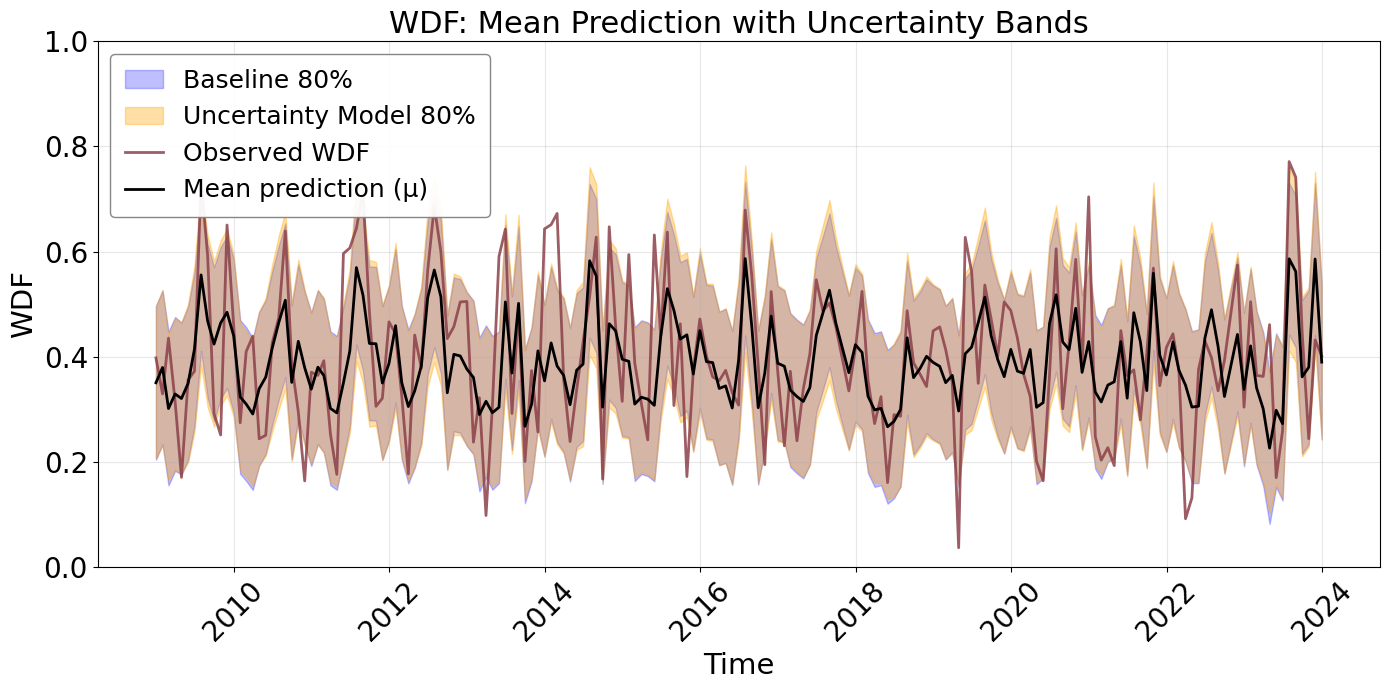


TIME SERIES PLOT SUMMARY

Data shown: Last 15 years (179 points)
Time range: 2008-12 to 2023-12

Model σ (mean): 0.1190
Model σ (std): 0.0074

80% interval width:
  Baseline (mean): 0.292 WDF units
  Model (mean): 0.304 WDF units

Points outside 80% CI (plotted data):
  Baseline: 34/179 (19.0%)
  Model: 32/179 (17.9%)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

y_true = data['y_true'].values
mu_pred = data['y_pred'].values  # Mean predictions from Stage 1
time_index = data['time'].values  # Time values

# Get sigma predictions from LinearRegression Config_1
lr_results = [r for r in results_list if r['model'] == 'Linear' and r['config'] == 'Config_1_Top2']

if lr_results:
    sigma_model = lr_results[0]['sigma_predictions']
    print(f"Using Linear Regression Config_1_Top2")

mu_tensor = torch.FloatTensor(mu_pred)
sigma_tensor = torch.FloatTensor(sigma_model)

qlo_model_80 = q_truncnorm_01(mu_tensor, sigma_tensor, 0.10).detach().numpy()
qhi_model_80 = q_truncnorm_01(mu_tensor, sigma_tensor, 0.90).detach().numpy()

# Get 80% CI from baseline (empirical quantiles)
baseline_lo_80 = baseline_bands['band_80%'][0].numpy()
baseline_hi_80 = baseline_bands['band_80%'][1].numpy()

# Sort by time for proper plotting
sort_idx = np.argsort(time_index)
time_sorted = time_index[sort_idx]
y_true_sorted = y_true[sort_idx]
mu_pred_sorted = mu_pred[sort_idx]
qlo_model_sorted = qlo_model_80[sort_idx]
qhi_model_sorted = qhi_model_80[sort_idx]
baseline_lo_sorted = baseline_lo_80[sort_idx]
baseline_hi_sorted = baseline_hi_80[sort_idx]

# Convert time to datetime for better x-axis formatting
time_datetime = pd.to_datetime(time_sorted)

# Filter to last 15 years only
cutoff_date = time_datetime.max() - pd.DateOffset(years=15)
mask_15yr = time_datetime >= cutoff_date

time_15yr = time_datetime[mask_15yr]
y_true_15yr = y_true_sorted[mask_15yr]
mu_pred_15yr = mu_pred_sorted[mask_15yr]
qlo_model_15yr = qlo_model_sorted[mask_15yr]
qhi_model_15yr = qhi_model_sorted[mask_15yr]
baseline_lo_15yr = baseline_lo_sorted[mask_15yr]
baseline_hi_15yr = baseline_hi_sorted[mask_15yr]

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

ax.fill_between(time_15yr, 
                baseline_lo_15yr,
                baseline_hi_15yr,
                alpha=0.25, color='blue', label='Baseline 80%')

# CRPS model (truncated normal) - orange
ax.fill_between(time_15yr, 
                qlo_model_15yr,
                qhi_model_15yr,
                alpha=0.35, color='orange', label='Uncertainty Model 80%')

# Plot actual values as line (behind the prediction) - darker, softer red
ax.plot(time_15yr, y_true_15yr, color='#8B4049', linewidth=2.0, 
        label='Observed WDF', zorder=2, alpha=0.85)

# Plot the mean prediction line (on top)
ax.plot(time_15yr, mu_pred_15yr, 'k-', linewidth=2.0, 
        label='Mean prediction (μ)', zorder=3)

# Formatting with larger fonts
ax.set_xlabel('Time', fontsize=21)
ax.set_ylabel('WDF', fontsize=21)
ax.set_title('WDF: Mean Prediction with Uncertainty Bands', fontsize=22)

# Set y-axis limits for WDF [0, 1]
ax.set_ylim(0, 1)

# Format x-axis with larger tick labels
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=20, rotation=45)
ax.tick_params(axis='y', labelsize=20)

# Legend with larger font, background box with rounded corners
ax.legend(loc='upper left', fontsize=18, 
          frameon=True, fancybox=True, framealpha=0.95, 
          edgecolor='gray', facecolor='white',
          borderpad=0.6, handlelength=1.5)

# Grid
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()